# Unifying Mixture Toxicity Datasets for LD₅₀ Prediction

This notebook constructs a unified mixture toxicity dataset by combining two independently prepared sources:

- Smyth DDI LD₅₀ dataset

- Acute Oral Toxicity mixture dataset

Key Objectives

- Load and standardize multiple mixture toxicity datasets

- Ensure consistent molecular representation using canonical SMILES

- Remove invalid or incomplete records

- Make drug pairs order-invariant

- Identify and resolve duplicate drug pairs across datasets

- Aggregate repeated measurements using the median

- Perform basic exploratory data analysis (EDA)

- Generate processed and model-ready datasets

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 31.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from google.colab import drive

drive.mount('/content/drive')
RDLogger.DisableLog('rdApp.*')

Mounted at /content/drive


In [3]:
base_path = '/content/drive/MyDrive/FYP/IRP/Data'

smyth_path = os.path.join(base_path, 'ddi_ld50_smyth', 'ddi_ld50_smyth_model_ready.csv')
acute_path = os.path.join(base_path, 'Acute_Oral_Toxicity', 'Acute_Oral_Toxicity_mixture_model_ready.csv')

print("Smyth path:", smyth_path)
print("Acute Oral path:", acute_path)

Smyth path: /content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_model_ready.csv
Acute Oral path: /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_model_ready.csv


In [4]:
def parse_smiles(smiles):
    try:
        if pd.isna(smiles):
            return None
        smiles = str(smiles).strip()
        if smiles == "":
            return None
        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        return mol
    except:
        return None

def canonicalize_smiles(smiles):
    mol = parse_smiles(smiles)
    if mol is None:
        return np.nan
    try:
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return np.nan

def is_valid_smiles(smiles):
    return parse_smiles(smiles) is not None

def make_order_invariant_pair(smiles_a, smiles_b):
    pair = sorted([smiles_a, smiles_b])
    return pair[0], pair[1]

def make_pair_key(smiles_a, smiles_b):
    a, b = make_order_invariant_pair(smiles_a, smiles_b)
    return f"{a}||{b}"

In [5]:
smyth_df = pd.read_csv(smyth_path)
acute_df = pd.read_csv(acute_path)

print("Smyth shape:", smyth_df.shape)
print("Acute Oral shape:", acute_df.shape)

display(smyth_df.head())
display(acute_df.head())

Smyth shape: (350, 3)
Acute Oral shape: (62, 3)


,SMILES_A,SMILES_B,Mixture_neglog
0,CC(=O)C,CC#N,1.382238
1,CC(=O)C,CC(=O)c1ccccc1,1.459831
2,CC(=O)C,C=CC#N,2.471304
3,CC(=O)C,Nc1ccccc1,1.736511
4,CC(=O)C,CCCCOCCO,1.458763


,SMILES_A,SMILES_B,Mixture_neglog_molkg
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919
1,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2.499312
2,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2.403102
3,CC(=NC#N)N(C)Cc1ccc(Cl)nc1,Cc1c(COC(=O)C2C(C=C(Cl)C(F)(F)F)C2(C)C)cccc1-c...,3.444070
4,OO,CC(=O)OO,2.277781


Standardize column names

In [6]:
# Smyth dataset: Mixture_neglog -> Target
smyth_df = smyth_df.rename(columns={
    "Mixture_neglog": "Target_neglog_molkg"
})

# Acute Oral dataset: Mixture_neglog_molkg -> Target
acute_df = acute_df.rename(columns={
    "Mixture_neglog_molkg": "Target_neglog_molkg"
})

# Keep only shared columns
smyth_df = smyth_df[["SMILES_A", "SMILES_B", "Target_neglog_molkg"]].copy()
acute_df = acute_df[["SMILES_A", "SMILES_B", "Target_neglog_molkg"]].copy()

# Add source labels
smyth_df["source"] = "Smyth"
acute_df["source"] = "Acute_Oral_Toxicity"

display(smyth_df.head())
display(acute_df.head())

,SMILES_A,SMILES_B,Target_neglog_molkg,source
0,CC(=O)C,CC#N,1.382238,Smyth
1,CC(=O)C,CC(=O)c1ccccc1,1.459831,Smyth
2,CC(=O)C,C=CC#N,2.471304,Smyth
3,CC(=O)C,Nc1ccccc1,1.736511,Smyth
4,CC(=O)C,CCCCOCCO,1.458763,Smyth


,SMILES_A,SMILES_B,Target_neglog_molkg,source
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity
1,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2.499312,Acute_Oral_Toxicity
2,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2.403102,Acute_Oral_Toxicity
3,CC(=NC#N)N(C)Cc1ccc(Cl)nc1,Cc1c(COC(=O)C2C(C=C(Cl)C(F)(F)F)C2(C)C)cccc1-c...,3.444070,Acute_Oral_Toxicity
4,OO,CC(=O)OO,2.277781,Acute_Oral_Toxicity


Canonicalize and validate SMILES

In [7]:
def clean_mixture_df(df_):
    df_ = df_.copy()
    df_["SMILES_A"] = df_["SMILES_A"].apply(canonicalize_smiles)
    df_["SMILES_B"] = df_["SMILES_B"].apply(canonicalize_smiles)

    df_["valid_A"] = df_["SMILES_A"].apply(is_valid_smiles)
    df_["valid_B"] = df_["SMILES_B"].apply(is_valid_smiles)

    df_ = df_.dropna(subset=["SMILES_A", "SMILES_B", "Target_neglog_molkg"]).copy()
    df_ = df_[(df_["valid_A"]) & (df_["valid_B"])].copy()

    return df_

smyth_df = clean_mixture_df(smyth_df)
acute_df = clean_mixture_df(acute_df)

print("Smyth valid rows:", len(smyth_df))
print("Acute Oral valid rows:", len(acute_df))

Smyth valid rows: 350
Acute Oral valid rows: 62


Make pair order-invariant

In [8]:
def reorder_pair_row(row):
    a, b = make_order_invariant_pair(row["SMILES_A"], row["SMILES_B"])
    row["SMILES_A"] = a
    row["SMILES_B"] = b
    return row

smyth_df = smyth_df.apply(reorder_pair_row, axis=1)
acute_df = acute_df.apply(reorder_pair_row, axis=1)

smyth_df["PairKey"] = smyth_df.apply(lambda x: make_pair_key(x["SMILES_A"], x["SMILES_B"]), axis=1)
acute_df["PairKey"] = acute_df.apply(lambda x: make_pair_key(x["SMILES_A"], x["SMILES_B"]), axis=1)

display(smyth_df.head())
display(acute_df.head())

,SMILES_A,SMILES_B,Target_neglog_molkg,source,valid_A,valid_B,PairKey
0,CC#N,CC(C)=O,1.382238,Smyth,True,True,CC#N||CC(C)=O
1,CC(=O)c1ccccc1,CC(C)=O,1.459831,Smyth,True,True,CC(=O)c1ccccc1||CC(C)=O
2,C=CC#N,CC(C)=O,2.471304,Smyth,True,True,C=CC#N||CC(C)=O
3,CC(C)=O,Nc1ccccc1,1.736511,Smyth,True,True,CC(C)=O||Nc1ccccc1
4,CC(C)=O,CCCCOCCO,1.458763,Smyth,True,True,CC(C)=O||CCCCOCCO


,SMILES_A,SMILES_B,Target_neglog_molkg,source,valid_A,valid_B,PairKey
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity,True,True,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1||CCCCC...
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312,Acute_Oral_Toxicity,True,True,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102,Acute_Oral_Toxicity,True,True,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...
3,CC(=NC#N)N(C)Cc1ccc(Cl)nc1,Cc1c(COC(=O)C2C(C=C(Cl)C(F)(F)F)C2(C)C)cccc1-c...,3.444070,Acute_Oral_Toxicity,True,True,CC(=NC#N)N(C)Cc1ccc(Cl)nc1||Cc1c(COC(=O)C2C(C=...
4,CC(=O)OO,OO,2.277781,Acute_Oral_Toxicity,True,True,CC(=O)OO||OO


Merge datasets

In [9]:
combined_df = pd.concat([smyth_df, acute_df], ignore_index=True)

print("Combined rows before deduplication:", len(combined_df))
print("Unique pair keys before deduplication:", combined_df["PairKey"].nunique())

combined_df.sample(5)

Combined rows before deduplication: 412
Unique pair keys before deduplication: 387


,SMILES_A,SMILES_B,Target_neglog_molkg,source,valid_A,valid_B,PairKey
347,CC(O)COC(C)COC(C)C,Cc1ccccc1,1.150740,Smyth,True,True,CC(O)COC(C)COC(C)C||Cc1ccccc1
248,C1COCCN1,CCO,1.465848,Smyth,True,True,C1COCCN1||CCO
273,C1COCCN1,C=O,1.478325,Smyth,True,True,C1COCCN1||C=O
123,C1COCCO1,CCCCOCCO,1.383834,Smyth,True,True,C1COCCO1||CCCCOCCO
78,C=CC#N,ClC(Cl)(Cl)Cl,2.557124,Smyth,True,True,C=CC#N||ClC(Cl)(Cl)Cl


Inspect duplicate pairs across datasets

In [10]:
duplicated_pairs = combined_df[combined_df.duplicated("PairKey", keep=False)].copy()

print("Rows belonging to duplicate pair groups:", len(duplicated_pairs))
print("Unique duplicated pairs:", duplicated_pairs["PairKey"].nunique())

if len(duplicated_pairs) > 0:
    display(duplicated_pairs.sort_values("PairKey").head(20))

Rows belonging to duplicate pair groups: 50
Unique duplicated pairs: 25


,SMILES_A,SMILES_B,Target_neglog_molkg,source,valid_A,valid_B,PairKey
303,C1COCCN1,CC(O)COC(C)COC(C)C,1.783887,Smyth,True,True,C1COCCN1||CC(O)COC(C)COC(C)C
304,C1COCCN1,CC(O)COC(C)COC(C)C,1.722097,Smyth,True,True,C1COCCN1||CC(O)COC(C)COC(C)C
214,C1COCCO1,CC(O)COC(C)COC(C)C,1.051663,Smyth,True,True,C1COCCO1||CC(O)COC(C)COC(C)C
213,C1COCCO1,CC(O)COC(C)COC(C)C,0.938800,Smyth,True,True,C1COCCO1||CC(O)COC(C)COC(C)C
96,C=CC#N,CC(O)COC(C)COC(C)C,2.638546,Smyth,True,True,C=CC#N||CC(O)COC(C)COC(C)C
97,C=CC#N,CC(O)COC(C)COC(C)C,2.650955,Smyth,True,True,C=CC#N||CC(O)COC(C)COC(C)C
244,C=CC(=O)OCC,CC(O)COC(C)COC(C)C,1.686193,Smyth,True,True,C=CC(=O)OCC||CC(O)COC(C)COC(C)C
243,C=CC(=O)OCC,CC(O)COC(C)COC(C)C,2.065984,Smyth,True,True,C=CC(=O)OCC||CC(O)COC(C)COC(C)C
282,C=O,CC(O)COC(C)COC(C)C,1.469500,Smyth,True,True,C=O||CC(O)COC(C)COC(C)C
283,C=O,CC(O)COC(C)COC(C)C,1.622509,Smyth,True,True,C=O||CC(O)COC(C)COC(C)C


Aggregate duplicate pairs using median

In [11]:
unified_mixture_df = combined_df.groupby("PairKey", as_index=False).agg({
    "SMILES_A": "first",
    "SMILES_B": "first",
    "Target_neglog_molkg": "median",
    "source": lambda x: ",".join(sorted(set(x)))
})

print("Unified rows after deduplication:", len(unified_mixture_df))
unified_mixture_df.head()

Unified rows after deduplication: 387


,PairKey,SMILES_A,SMILES_B,Target_neglog_molkg,source
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1||CCCCC...,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312,Acute_Oral_Toxicity
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102,Acute_Oral_Toxicity
3,C1COCCN1||C1COCCO1,C1COCCN1,C1COCCO1,1.359363,Smyth
4,C1COCCN1||C=CC#N,C1COCCN1,C=CC#N,2.130152,Smyth


In [12]:
print("Final dataset shape:", unified_mixture_df.shape)
print("\nTarget summary:")
print(unified_mixture_df["Target_neglog_molkg"].describe())

print("\nUnique SMILES_A:", unified_mixture_df["SMILES_A"].nunique())
print("Unique SMILES_B:", unified_mixture_df["SMILES_B"].nunique())
print("Unique pair keys:", unified_mixture_df["PairKey"].nunique())

Final dataset shape: (387, 5)

Target summary:
count    387.000000
mean       1.792278
std        0.692191
min        0.146880
25%        1.371682
50%        1.708999
75%        2.141182
max        4.539128
Name: Target_neglog_molkg, dtype: float64

Unique SMILES_A: 74
Unique SMILES_B: 71
Unique pair keys: 387


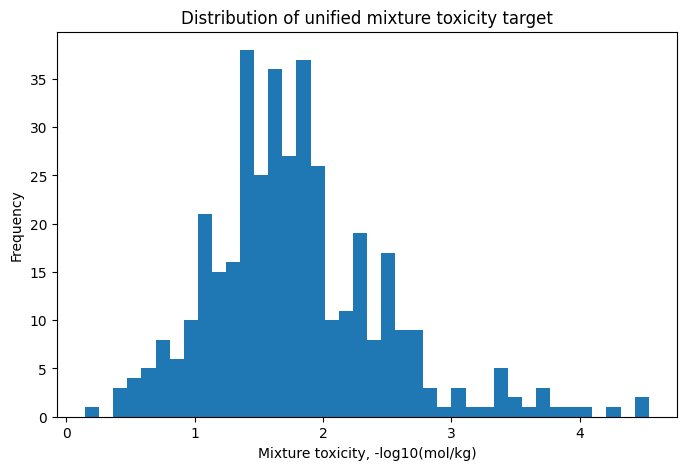

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(unified_mixture_df["Target_neglog_molkg"], bins=40)
plt.xlabel("Mixture toxicity, -log10(mol/kg)")
plt.ylabel("Frequency")
plt.title("Distribution of unified mixture toxicity target")
plt.show()

| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


In [14]:
print(unified_mixture_df["source"].value_counts())

source
Smyth                  325
Acute_Oral_Toxicity     62
Name: count, dtype: int64


In [15]:
processed_output_path = os.path.join(base_path, 'unified_mixture_toxicity_processed.csv')
unified_mixture_df.to_csv(processed_output_path, index=False)
print(f"Saved processed unified dataset to: {processed_output_path}")

model_ready_df = unified_mixture_df[["SMILES_A", "SMILES_B", "Target_neglog_molkg"]].copy()

model_ready_output_path = os.path.join(base_path, 'unified_mixture_toxicity_model_ready.csv')
model_ready_df.to_csv(model_ready_output_path, index=False)
print(f"Saved model-ready unified dataset to: {model_ready_output_path}")

Saved processed unified dataset to: /content/drive/MyDrive/FYP/IRP/Data/unified_mixture_toxicity_processed.csv
Saved model-ready unified dataset to: /content/drive/MyDrive/FYP/IRP/Data/unified_mixture_toxicity_model_ready.csv


In [18]:
model_ready_df.head()

,SMILES_A,SMILES_B,Target_neglog_molkg
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102
3,C1COCCN1,C1COCCO1,1.359363
4,C1COCCN1,C=CC#N,2.130152


In [17]:
model_ready_df['Target_neglog_molkg'].describe()

,Target_neglog_molkg
count,387.000000
mean,1.792278
std,0.692191
min,0.146880
25%,1.371682
50%,1.708999
75%,2.141182
max,4.539128
